<a href="https://colab.research.google.com/github/oamerciful-rgb/math-for-data-science/blob/main/maths_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

A = np.array([[2,-1,1,0],
              [1,1,0,1],
              [-1,0,3,-1],
              [0,1,1,1]], dtype=float)

b = np.array([150, 420, 100, 380], dtype=float)

x = np.linalg.solve(A, b)
print(x)

[138.33333333 225.          98.33333333  56.66666667]


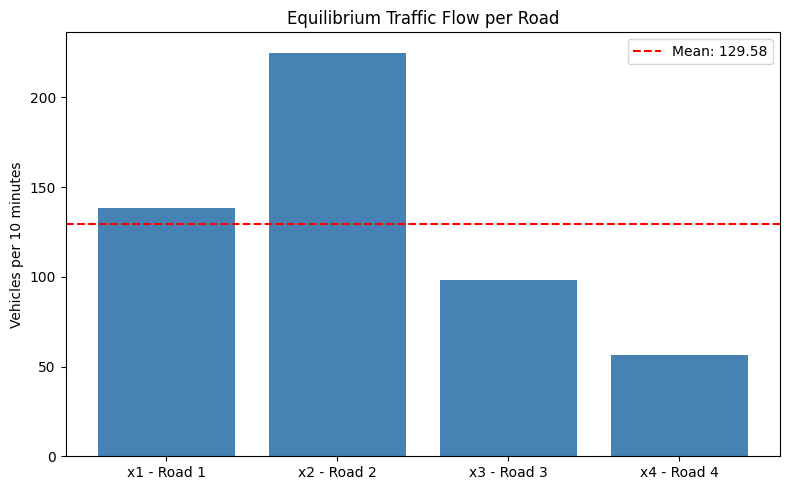

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

roads = ['x1 - Road 1', 'x2 - Road 2', 'x3 - Road 3', 'x4 - Road 4']
flows = [138.33, 225, 98.33, 56.67]
mean_flow = np.mean(flows)

plt.figure(figsize=(8, 5))
plt.bar(roads, flows, color='steelblue')
plt.axhline(y=mean_flow, color='red', linestyle='--', label=f'Mean: {mean_flow:.2f}')
plt.title('Equilibrium Traffic Flow per Road')
plt.ylabel('Vehicles per 10 minutes')
plt.legend()
plt.tight_layout()
plt.savefig('traffic_flow.png')
plt.show()

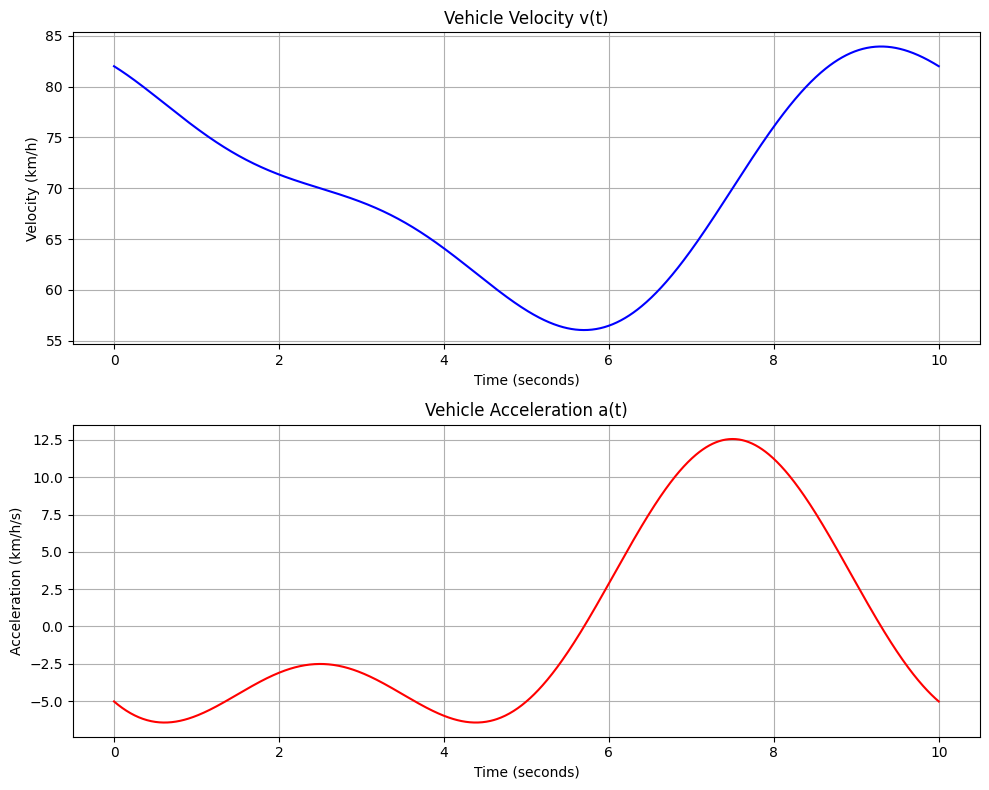

In [ ]:
# Here's the Python code to plot both v(t) and a(t):
import numpy as np
import matplotlib.pyplot as plt

# Time array
t = np.linspace(0, 10, 1000)

# Velocity function
v = 70 + 12*np.cos(np.pi*t/5) - 4*np.sin(2*np.pi*t/5)

# Acceleration function (in km/h/s)
a = -12*(np.pi/5)*np.sin(np.pi*t/5) - 4*(2*np.pi/5)*np.cos(2*np.pi*t/5)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Velocity plot
ax1.plot(t, v, color='blue')
ax1.set_title('Vehicle Velocity v(t)')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Velocity (km/h)')
ax1.grid(True)

# Acceleration plot
ax2.plot(t, a, color='red')
ax2.set_title('Vehicle Acceleration a(t)')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Acceleration (km/h/s)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('velocity_acceleration.png')
plt.show()

In [ ]:
import numpy as np

t = np.linspace(0, 10, 1000)
a = -12*(np.pi/5)*np.sin(np.pi*t/5) - 4*(2*np.pi/5)*np.cos(2*np.pi*t/5)

print("Peak acceleration:", round(np.max(a), 2), "km/h/s =", round(np.max(a)/3.6, 2), "m/s²")
print("Peak deceleration:", round(np.min(a), 2), "km/h/s =", round(np.min(a)/3.6, 2), "m/s²")
print("Average acceleration:", round(np.mean(a), 2), "km/h/s")

Peak acceleration: 12.57 km/h/s = 3.49 m/s²
Peak deceleration: -6.44 km/h/s = -1.79 m/s²
Average acceleration: -0.01 km/h/s


In [ ]:
from scipy.signal import argrelextrema

# Find critical points where acceleration = 0
t = np.linspace(0, 10, 1000)
v = 70 + 12*np.cos(np.pi*t/5) - 4*np.sin(2*np.pi*t/5)

# Find local maxima and minima
max_idx = argrelextrema(v, np.greater)[0]
min_idx = argrelextrema(v, np.less)[0]

print("Maximum velocity points:")
for i in max_idx:
    print(f"  t = {t[i]:.2f}s, v = {v[i]:.2f} km/h")

print("Minimum velocity points:")
for i in min_idx:
    print(f"  t = {t[i]:.2f}s, v = {v[i]:.2f} km/h")

Maximum velocity points:
  t = 9.30s, v = 83.94 km/h
Minimum velocity points:
  t = 5.70s, v = 56.06 km/h


In [ ]:
from scipy import stats

# Define the distribution
mu = 0.85
sigma = 0.25

# Calculate probabilities
p_rapid = stats.norm.cdf(0.5, mu, sigma)
p_delayed = 1 - stats.norm.cdf(1.2, mu, sigma)
p_normal = stats.norm.cdf(1.1, mu, sigma) - stats.norm.cdf(0.6, mu, sigma)

# Z-scores
z_05 = (0.5 - mu) / sigma
z_12 = (1.2 - mu) / sigma

print("P(T < 0.5s) rapid:", round(p_rapid*100, 2), "%")
print("P(T > 1.2s) delayed:", round(p_delayed*100, 2), "%")
print("P(0.6 < T < 1.1s) normal:", round(p_normal*100, 2), "%")
print("Z for T=0.5s:", round(z_05, 2))
print("Z for T=1.2s:", round(z_12, 2))

P(T < 0.5s) rapid: 8.08 %
P(T > 1.2s) delayed: 8.08 %
P(0.6 < T < 1.1s) normal: 68.27 %
Z for T=0.5s: -1.4
Z for T=1.2s: 1.4


In [ ]:
speed_kmh = 70
speed_ms = speed_kmh / 3.6
reaction_time = 1.261

distance = speed_ms * reaction_time
print("Speed in m/s:", round(speed_ms, 2))
print("Distance travelled:", round(distance, 2), "metres")

Speed in m/s: 19.44
Distance travelled: 24.52 metres


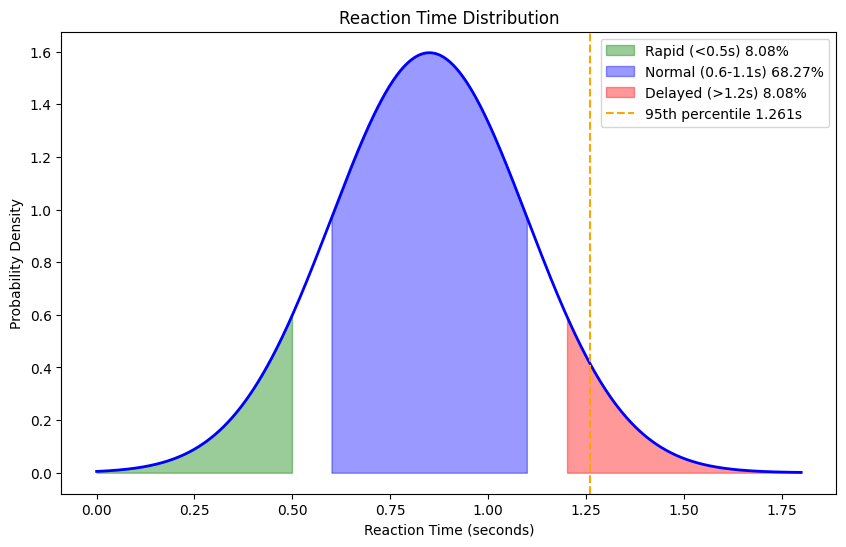

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mu, sigma = 0.85, 0.25
x = np.linspace(0, 1.8, 1000)
y = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2)

# Green = fast (under 0.5s)
x_green = x[x < 0.5]
plt.fill_between(x_green, stats.norm.pdf(x_green, mu, sigma), color='green', alpha=0.4, label='Rapid (<0.5s) 8.08%')

# Blue = normal (0.6 to 1.1s)
x_blue = x[(x >= 0.6) & (x <= 1.1)]
plt.fill_between(x_blue, stats.norm.pdf(x_blue, mu, sigma), color='blue', alpha=0.4, label='Normal (0.6-1.1s) 68.27%')

# Red = delayed (over 1.2s)
x_red = x[x > 1.2]
plt.fill_between(x_red, stats.norm.pdf(x_red, mu, sigma), color='red', alpha=0.4, label='Delayed (>1.2s) 8.08%')

plt.axvline(x=1.261, color='orange', linestyle='--', label='95th percentile 1.261s')
plt.title('Reaction Time Distribution')
plt.xlabel('Reaction Time (seconds)')
plt.ylabel('Probability Density')
plt.legend()
plt.savefig('reaction_distribution.png')
plt.show()

In [ ]:
speeds = [49, 52, 55, 48, 50, 53, 57, 51, 54, 49, 52, 56]
over_limit = sum(1 for s in speeds if s > 50)
percentage = (over_limit / len(speeds)) * 100
print("Vehicles over 50:", over_limit)
print("Percentage:", round(percentage, 1), "%")

Vehicles over 50: 8
Percentage: 66.7 %


In [ ]:
# Type in your 12 vehicle speeds here
speeds = [47.2, 51.4, 49.8, 49, 52, 55, 48, 50, 53, 57, 51, 54]  # add all 12 speeds

import numpy as np
print("Mean:", round(np.mean(speeds), 2))
print("Median:", round(np.median(speeds), 2))
print("Std Dev:", round(np.std(speeds, ddof=1), 2))
print("Variance:", round(np.var(speeds, ddof=1), 2))
print("Min:", min(speeds))
print("Max:", max(speeds))

Mean: 51.45
Median: 51.2
Std Dev: 2.92
Variance: 8.51
Min: 47.2
Max: 57


In [ ]:
speeds = [49, 52, 55, 48, 50, 53, 57, 51, 54, 49, 52, 56]
over_limit = sum(1 for s in speeds if s > 50)
percentage = (over_limit / len(speeds)) * 100
print("Vehicles over 50:", over_limit)
print("Percentage:", round(percentage, 1), "%")

Vehicles over 50: 8
Percentage: 66.7 %


In [ ]:
speeds = [49, 52, 55, 48, 50, 53, 57, 51, 54, 49, 52, 56]
speed_limit = 50

over = [s for s in speeds if s > speed_limit]
under = [s for s in speeds if s <= speed_limit]

print("Vehicles over limit:", len(over))
print("Vehicles within limit:", len(under))
print("% over limit:", round(len(over)/len(speeds)*100, 1))
print("Average speed over limit:", round(sum(over)/len(over), 2))
print("Highest speed:", max(speeds))
print("How much above mean:", round(52.17 - 50, 2), "km/h above limit")

Vehicles over limit: 8
Vehicles within limit: 4
% over limit: 66.7
Average speed over limit: 53.75
Highest speed: 57
How much above mean: 2.17 km/h above limit


In [ ]:
from scipy import stats
import numpy as np

speeds = np.array([49, 52, 55, 48, 50, 53, 57, 51, 54, 49, 52, 56])

# One-sample t-test
t_stat, p_two = stats.ttest_1samp(speeds, 50)
p_one = p_two / 2

# Degrees of freedom
df = len(speeds) - 1

# Critical value
t_crit = stats.t.ppf(0.95, df)

# Effect size
cohens_d = (np.mean(speeds) - 50) / np.std(speeds, ddof=1)

print(f"t-statistic: {t_stat:.4f}")
print(f"Degrees of freedom: {df}")
print(f"p-value (one-tailed): {p_one:.4f}")
print(f"Critical value (a=0.05): {t_crit:.4f}")
print(f"Cohen's d: {cohens_d:.4f}")
print(f"Reject H0: {t_stat > t_crit}")

t-statistic: 2.5721
Degrees of freedom: 11
p-value (one-tailed): 0.0130
Critical value (a=0.05): 1.7959
Cohen's d: 0.7425
Reject H0: True
